# Bulk Tanimoto Similarity: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 2 of the nvMolKit acceleration series.**

Pairwise [Tanimoto similarity](https://www.rdkit.org/docs/GettingStartedInPython.html#fingerprinting-and-molecular-similarity)
over a fingerprint set is the core of similarity search, diversity selection, and clustering. The all-to-all
similarity matrix is **O(n²)** — doubling the library quadruples the work — so it is an even better fit for the
GPU than fingerprinting itself (Tutorial 1).

This notebook compares:

- **RDKit (CPU)** — `DataStructs.BulkTanimotoSimilarity(fps[i], fps)` looped over rows to build the full matrix.
- **nvMolKit (GPU)** — `nvmolkit.similarity.crossTanimotoSimilarity(fps)`, a single batched kernel.

We confirm the matrices match, then watch the speedup grow with library size. (Cosine similarity has an
identical API via `crossCosineSimilarity`.)

> Run from this `examples/tutorials/` directory so `./nvmolkit` in the repo root doesn't shadow the install.


## 1. Setup and GPU check

In [1]:
import time

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, rdFingerprintGenerator
from rdkit.DataStructs import BulkTanimotoSimilarity

import nvmolkit
from nvmolkit.fingerprints import MorganFingerprintGenerator
from nvmolkit.similarity import crossTanimotoSimilarity, crossTanimotoSimilarityMemoryConstrained

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
FP_RADIUS = 3
FP_NBITS = 2048
N_CPU_THREADS = 16            # for fingerprint preprocessing + (implicitly) RDKit
SIZES = [100, 500, 1000, 2000, 5000, 10000]
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"radius={FP_RADIUS}, fpSize={FP_NBITS}")

radius=3, fpSize=2048


## 3. Load molecules and precompute fingerprints once

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=max(SIZES)).iloc[:, 0].tolist()
mols_all = [m for m in (MolFromSmiles(s) for s in smis) if m is not None]
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Parsed {len(mols_all)} molecules; sweep sizes = {SIZES}")

# RDKit fingerprints (list of ExplicitBitVect)
rd_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
rd_fps_all = rd_gen.GetFingerprints(mols_all, numThreads=N_CPU_THREADS)

# nvMolKit fingerprints (packed int32 tensor on the GPU)
nv_gen = MorganFingerprintGenerator(radius=FP_RADIUS, fpSize=FP_NBITS)
nv_fps_all = nv_gen.GetFingerprints(mols_all, num_threads=N_CPU_THREADS).torch()
torch.cuda.synchronize()
print(f"RDKit fps: {len(rd_fps_all)} | nvMolKit fps tensor: {tuple(nv_fps_all.shape)} {nv_fps_all.dtype}")

Parsed 10000 molecules; sweep sizes = [100, 500, 1000, 2000, 5000, 10000]
RDKit fps: 10000 | nvMolKit fps tensor: (10000, 64) torch.int32


## 4. Define the two backends

Both build the full `n x n` Tanimoto matrix. We time *only* the similarity computation; fingerprints are
precomputed above so the comparison isolates the matrix kernel.

In [4]:
def rdkit_similarity(rd_fps):
    n = len(rd_fps)
    mat = np.empty((n, n), dtype=np.float64)
    for i in range(n):
        mat[i] = BulkTanimotoSimilarity(rd_fps[i], rd_fps)
    return mat


def nvmolkit_similarity(nv_fps):
    mat = crossTanimotoSimilarity(nv_fps).torch()
    torch.cuda.synchronize()
    return mat  # (n, n) tensor on GPU

## 5. Correctness check

Confirm the GPU matrix matches RDKit before timing.

In [5]:
k = 1000
rd_mat = rdkit_similarity(rd_fps_all[:k])
nv_mat = nvmolkit_similarity(nv_fps_all[:k]).cpu().numpy()

max_abs_diff = np.abs(rd_mat - nv_mat).max()
print(f"matrix shape       : {nv_mat.shape}")
print(f"max abs difference : {max_abs_diff:.2e}")
assert np.allclose(rd_mat, nv_mat, atol=1e-5), "Tanimoto matrices differ!"
print("\nOK - GPU similarity matrix matches RDKit.")

matrix shape       : (1000, 1000)
max abs difference : 1.19e-07

OK - GPU similarity matrix matches RDKit.


## 6. Warm up the GPU

In [6]:
_ = nvmolkit_similarity(nv_fps_all[:256])
torch.cuda.synchronize()
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

The matrix is O(n²), so RDKit's per-row Python loop slows down quadratically while the GPU kernel absorbs the
growth far better.

In [7]:
def timeit(fn, *args, repeats=3):
    best = float("inf")
    for _ in range(repeats):
        t = time.perf_counter()
        fn(*args)
        torch.cuda.synchronize()
        best = min(best, time.perf_counter() - t)
    return best


rows = []
for n in SIZES:
    t_rd = timeit(rdkit_similarity, rd_fps_all[:n], repeats=2)
    t_gpu = timeit(nvmolkit_similarity, nv_fps_all[:n], repeats=3)
    rows.append({
        "n_mols": n,
        "pairs": n * n,
        "rdkit_cpu_s": t_rd,
        "nvmolkit_gpu_s": t_gpu,
        "speedup": t_rd / t_gpu,
    })
    print(f"n={n:6d} | pairs={n*n:>11,d} | RDKit {t_rd:8.3f}s | nvMolKit {t_gpu:7.4f}s | speedup {t_rd/t_gpu:7.1f}x")

df = pd.DataFrame(rows)
df

n=   100 | pairs=     10,000 | RDKit    0.001s | nvMolKit  0.0010s | speedup     1.4x
n=   500 | pairs=    250,000 | RDKit    0.033s | nvMolKit  0.0010s | speedup    33.9x
n=  1000 | pairs=  1,000,000 | RDKit    0.139s | nvMolKit  0.0010s | speedup   139.1x
n=  2000 | pairs=  4,000,000 | RDKit    0.677s | nvMolKit  0.0020s | speedup   341.5x
n=  5000 | pairs= 25,000,000 | RDKit    4.469s | nvMolKit  0.0033s | speedup  1351.7x
n= 10000 | pairs=100,000,000 | RDKit   17.775s | nvMolKit  0.0041s | speedup  4295.4x


,n_mols,pairs,rdkit_cpu_s,nvmolkit_gpu_s,speedup
0,100,10000,0.001405,0.000989,1.421716
1,500,250000,0.033109,0.000978,33.858774
2,1000,1000000,0.139197,0.001001,139.107980
3,2000,4000000,0.676790,0.001982,341.505000
4,5000,25000000,4.468804,0.003306,1351.728706
5,10000,100000000,17.775091,0.004138,4295.434289


## 8. Plot: runtime and speedup vs library size

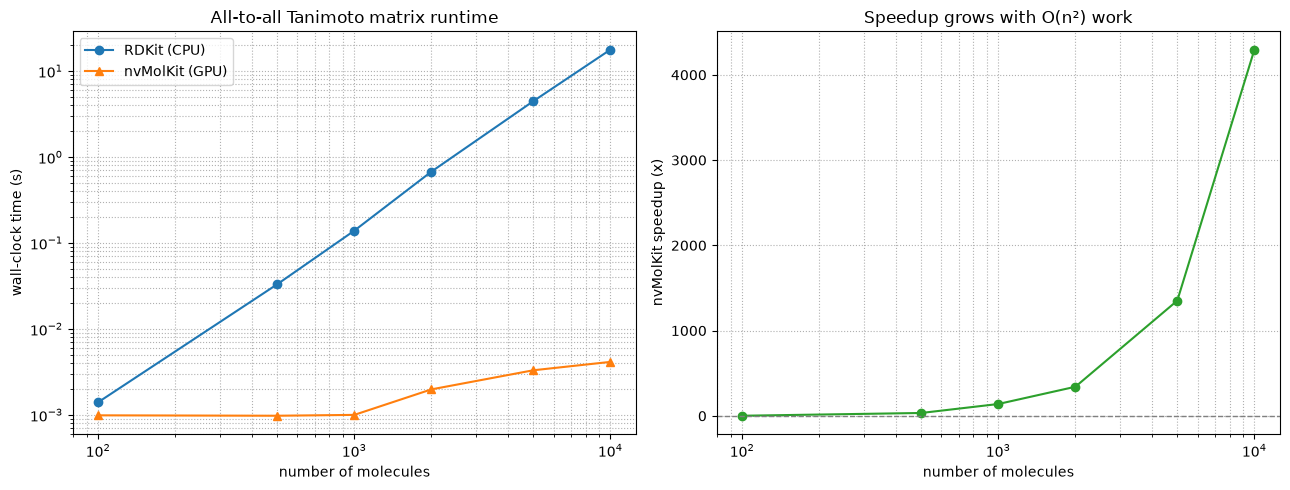

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_cpu_s"], "o-", label="RDKit (CPU)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title("All-to-all Tanimoto matrix runtime")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup"], "o-", color="C2")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("Speedup grows with O(n²) work")
ax2.set_xscale("log")
ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

## 9. When the matrix doesn't fit: `crossTanimotoSimilarity*MemoryConstrained`

`crossTanimotoSimilarity` returns the full matrix on the GPU. For very large libraries the `n x n` matrix may
exceed GPU memory. The memory-constrained variant computes in chunks on the GPU and returns a numpy array on the
CPU instead (it still requires the full matrix to fit in host RAM).

In [9]:
mc = crossTanimotoSimilarityMemoryConstrained(nv_fps_all[:1000])
print(f"type: {type(mc).__name__}, shape: {mc.shape}, dtype: {mc.dtype}")
print(f"matches GPU result: {np.allclose(mc, nv_mat, atol=1e-5)}")

type: ndarray, shape: (1000, 1000), dtype: float64
matches GPU result: True


## 10. Takeaways

- **Same matrix.** GPU Tanimoto values match RDKit to floating-point tolerance.
- **O(n²) is the GPU's home turf.** Because the work grows quadratically with library size, the GPU speedup is
  larger here than for fingerprinting and keeps climbing as the set grows — the regime that dominates virtual
  screening and library clustering.
- **Chain it on-device.** `crossTanimotoSimilarity` accepts nvMolKit fingerprints (or any packed tensor on the
  GPU) directly, so fingerprint -> similarity stays on the GPU with no host round-trip.
- **Out-of-core option.** Use the `*MemoryConstrained` variants when the matrix is too large to materialize on
  the GPU.

**Next:** Tutorial 3 moves to 3D — GPU-accelerated ETKDG conformer embedding.